#Customer Churn Prediction Using Machine Learning

##Project Overview

Customer churn refers to customers who stop using a company's service. Predicting churn helps businesses take preventive actions such as targeted marketing, discounts, or customer engagement strategies.

##Objectives

>Analyze customer data to understand churn behavior

>Perform Exploratory Data Analysis (EDA)

>Train classification models

>Evaluate performance using Accuracy, Recall, and ROC-AUC

>Algorithms Used

>Logistic Regression

>Random Forest
>XGBoost

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

##Load Dataset
Dataset Overview

The dataset contains information about telecom customers, including demographic details, account information, and services used. The objective is to predict whether a customer will churn (leave the service) or continue using the service.

Total Records: 7043 customers

Total Features: 21 columns

Target Variable: Churn

Type of Problem: Binary Classification

In [2]:
from google.colab import files
upload = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##Data Preprocessing

In [9]:
#Removing Customer ID
df.drop("customerID", axis=1, inplace=True)

In [10]:
#Converting TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_339/373870527.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


##Exploratory Data Analysis (EDA)

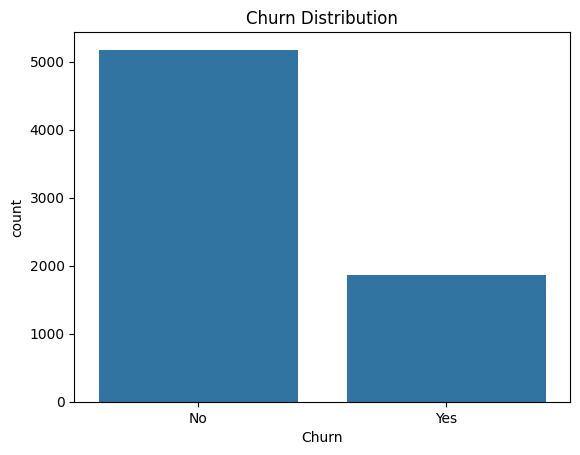

In [11]:
#Churn Distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

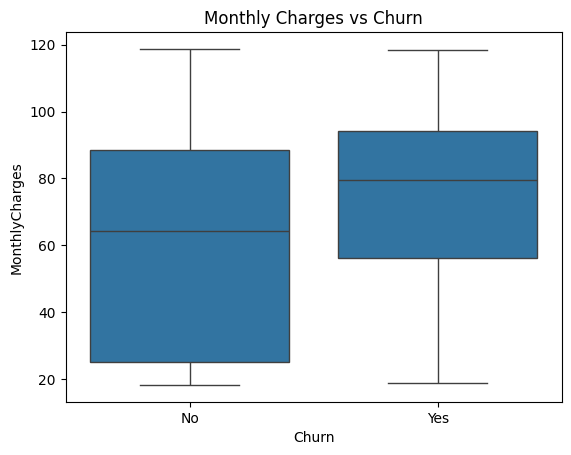

In [12]:
#Monthly Charges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

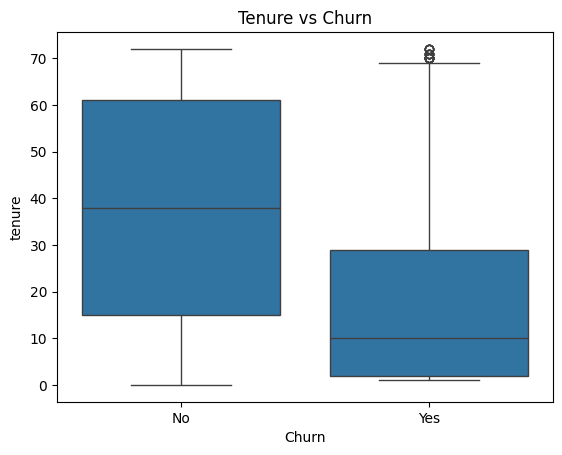

In [14]:
#Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

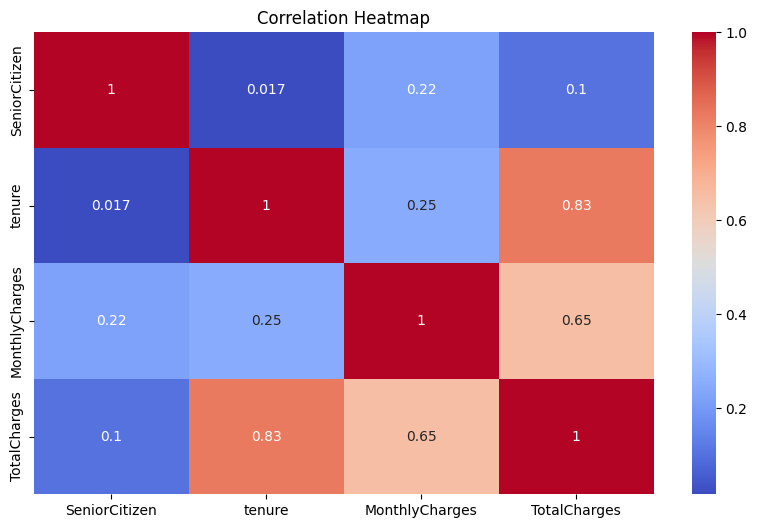

In [15]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
#Encoding Categorical Variables
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

##Train-Test Split

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
#Logistic Regression Model
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [20]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))

Accuracy: 0.815471965933286
Recall: 0.579088471849866
ROC-AUC: 0.7398338112145082


##Random Forest Model

In [21]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [22]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.7984386089425124
Recall: 0.47989276139410186
ROC-AUC: 0.6965100872607575


##XGBoost Model

In [23]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:36:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [24]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

Accuracy: 0.794180269694819
Recall: 0.5201072386058981
ROC-AUC: 0.7064821907315205


##ROC Curve

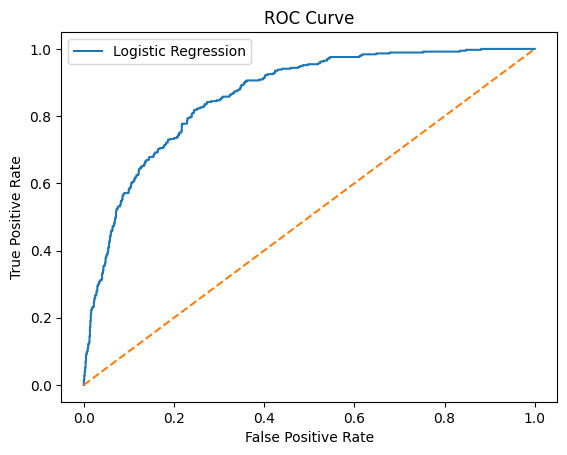

In [25]:
log_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, log_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##Model Comparison

In [26]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]

accuracy = [
accuracy_score(y_test, y_pred_log),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_xgb)
]

recall = [
recall_score(y_test, y_pred_log),
recall_score(y_test, y_pred_rf),
recall_score(y_test, y_pred_xgb)
]

roc_auc = [
roc_auc_score(y_test, y_pred_log),
roc_auc_score(y_test, y_pred_rf),
roc_auc_score(y_test, y_pred_xgb)
]

results = pd.DataFrame({
"Model":models,
"Accuracy":accuracy,
"Recall":recall,
"ROC-AUC":roc_auc
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.815472,0.579088,0.739834
1,Random Forest,0.798439,0.479893,0.696510
2,XGBoost,0.794180,0.520107,0.706482


##Conclusion

Key findings:

Customers with higher monthly charges are more likely to churn.

Customers with shorter tenure show higher churn probability.

XGBoost and Random Forest generally perform better than Logistic Regression.

Business impact:

Identify at-risk customers early

Offer targeted retention strategies

Improve customer satisfaction